# 📡 Analyse PySpark — Telco Customer Churn
> Ce notebook analyse le dataset Telco Customer Churn avec PySpark.
> Les résultats sont exportés en CSV dans `../data/` pour être affichés dans l'appli Streamlit.

## ⚙️ ÉTAPE 1 — Démarrer la session Spark

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, sum as spark_sum, avg, count, round as spark_round,
    when, desc, asc
)
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import os

spark = SparkSession.builder \
    .appName("TelcoChurnAnalysis") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("✅ Spark démarré — version :", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/22 21:23:04 WARN Utils: Your hostname, taoufik-HP-EliteBook-840-G7-Notebook-PC, resolves to a loopback address: 127.0.1.1; using 100.121.196.186 instead (on interface wlp0s20f3)
26/06/22 21:23:04 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/22 21:23:06 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✅ Spark démarré — version : 4.1.2


## 📂 ÉTAPE 2 — Charger le dataset

In [2]:
DATA_PATH = "../data/cleanedData.csv"
OUTPUT_DIR = "../data"

df = spark.read.csv(DATA_PATH, header=True, inferSchema=True)

print(f"✅ Dataset chargé : {df.count()} lignes, {len(df.columns)} colonnes")
df.printSchema()

✅ Dataset chargé : 7032 lignes, 21 colonnes
root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- OnlineBackup: string (nullable = true)
 |-- DeviceProtection: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- StreamingMovies: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: double (nullable = true)
 |-- Churn: string (nullable = true)



## 🔍 ÉTAPE 3 — Exploration initiale

In [3]:
# Aperçu des premières lignes
print("── Aperçu des données ──")
df.show(5, truncate=False)

── Aperçu des données ──
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+----------------+-------------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity     |OnlineBackup       |DeviceProtection   |TechSupport        |StreamingTV        |StreamingMovies    |Contract      |PaperlessBilling|PaymentMethod            |MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+--------------+----------------+-------------------------+--------------+------------+-----+
|3655-SNQYZ|Female|0          

In [4]:
# Statistiques descriptives des colonnes numériques
print("── Statistiques descriptives ──")
df.describe(["tenure", "MonthlyCharges", "TotalCharges"]).show()

── Statistiques descriptives ──


[Stage 6:>                                                          (0 + 1) / 1]

+-------+------------------+------------------+------------------+
|summary|            tenure|    MonthlyCharges|      TotalCharges|
+-------+------------------+------------------+------------------+
|  count|              7032|              7032|              7032|
|   mean|32.421786120591584| 64.79820819112607|2283.3004408418687|
| stddev|24.545259709263295|30.085973884049867|2266.7713618831417|
|    min|                 1|             18.25|              18.8|
|    max|                72|            118.75|            8684.8|
+-------+------------------+------------------+------------------+



In [5]:
# Vérification des valeurs nulles
print("── Valeurs nulles par colonne ──")
null_counts = df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
])
null_counts.show()

── Valeurs nulles par colonne ──
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|OnlineBackup|DeviceProtection|TechSupport|StreamingTV|StreamingMovies|Contract|PaperlessBilling|PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+------------+----------------+-----------+-----------+---------------+--------+----------------+-------------+--------------+------------+-----+
|         0|     0|            0|      0|         0|     0|           0|            0|              0|             0|           0|               0|          0|          0|          

## 📊 ÉTAPE 4 — Analyse du Churn Global

In [6]:
# Distribution churn Yes/No
total = df.count()
churn_global = df.groupBy("Churn").count() \
    .withColumn("Pourcentage", spark_round(col("count") / total * 100, 2)) \
    .orderBy("Churn")

print("── Distribution du Churn ──")
churn_global.show()

# Export CSV pour Streamlit
churn_global.toPandas().to_csv(f"{OUTPUT_DIR}/analyse_churn_global.csv", index=False)
print("✅ Exporté : analyse_churn_global.csv")

── Distribution du Churn ──
+-----+-----+-----------+
|Churn|count|Pourcentage|
+-----+-----+-----------+
|   No| 5163|      73.42|
|  Yes| 1869|      26.58|
+-----+-----+-----------+

✅ Exporté : analyse_churn_global.csv


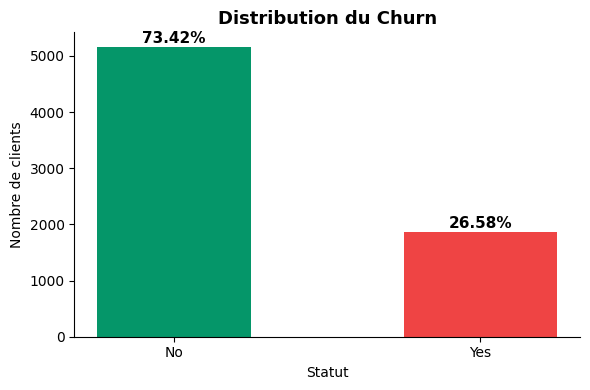

In [7]:
# Visualisation
df_churn_pd = churn_global.toPandas()
colors = ["#059669" if c == "No" else "#ef4444" for c in df_churn_pd["Churn"]]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(df_churn_pd["Churn"], df_churn_pd["count"], color=colors, width=0.5, edgecolor="none")
for bar, row in zip(bars, df_churn_pd.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
            f"{row.Pourcentage}%", ha="center", fontsize=11, fontweight="bold")
ax.set_title("Distribution du Churn", fontweight="bold", fontsize=13)
ax.set_xlabel("Statut") ; ax.set_ylabel("Nombre de clients")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout() ; plt.show()

## 📋 ÉTAPE 5 — Churn par type de Contrat

In [8]:
churn_contrat = df.groupBy("Contract").agg(
    count("*").alias("Total"),
    spark_sum(when(col("Churn") == "Yes", 1).otherwise(0)).alias("Churned"),
    spark_sum(when(col("Churn") == "No", 1).otherwise(0)).alias("Active")
).withColumn(
    "Taux_Churn_%", spark_round(col("Churned") / col("Total") * 100, 1)
).orderBy(desc("Taux_Churn_%"))

print("── Churn par Contrat ──")
churn_contrat.show()

churn_contrat.toPandas().to_csv(f"{OUTPUT_DIR}/analyse_churn_contrat.csv", index=False)
print("✅ Exporté : analyse_churn_contrat.csv")

── Churn par Contrat ──
+--------------+-----+-------+------+------------+
|      Contract|Total|Churned|Active|Taux_Churn_%|
+--------------+-----+-------+------+------------+
|Month-to-month| 3875|   1655|  2220|        42.7|
|      One year| 1472|    166|  1306|        11.3|
|      Two year| 1685|     48|  1637|         2.8|
+--------------+-----+-------+------+------------+

✅ Exporté : analyse_churn_contrat.csv


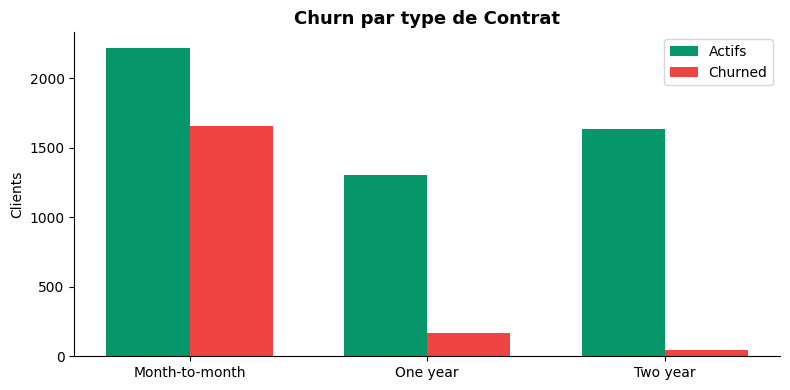

In [9]:
df_contrat_pd = churn_contrat.toPandas()

fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(df_contrat_pd))
width = 0.35
ax.bar([i - width/2 for i in x], df_contrat_pd["Active"],   width, label="Actifs",  color="#059669", edgecolor="none")
ax.bar([i + width/2 for i in x], df_contrat_pd["Churned"],  width, label="Churned", color="#ef4444", edgecolor="none")
ax.set_xticks(list(x)) ; ax.set_xticklabels(df_contrat_pd["Contract"], fontsize=10)
ax.set_title("Churn par type de Contrat", fontweight="bold", fontsize=13)
ax.set_ylabel("Clients") ; ax.legend()
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout() ; plt.show()

## 🌐 ÉTAPE 6 — Churn par Service Internet

In [10]:
churn_internet = df.groupBy("InternetService").agg(
    count("*").alias("Total"),
    spark_sum(when(col("Churn") == "Yes", 1).otherwise(0)).alias("Churned"),
    spark_sum(when(col("Churn") == "No", 1).otherwise(0)).alias("Active")
).withColumn(
    "Taux_Churn_%", spark_round(col("Churned") / col("Total") * 100, 1)
).orderBy(desc("Taux_Churn_%"))

print("── Churn par Service Internet ──")
churn_internet.show()

churn_internet.toPandas().to_csv(f"{OUTPUT_DIR}/analyse_churn_internet.csv", index=False)
print("✅ Exporté : analyse_churn_internet.csv")

── Churn par Service Internet ──
+---------------+-----+-------+------+------------+
|InternetService|Total|Churned|Active|Taux_Churn_%|
+---------------+-----+-------+------+------------+
|    Fiber optic| 3096|   1297|  1799|        41.9|
|            DSL| 2416|    459|  1957|        19.0|
|             No| 1520|    113|  1407|         7.4|
+---------------+-----+-------+------+------------+

✅ Exporté : analyse_churn_internet.csv


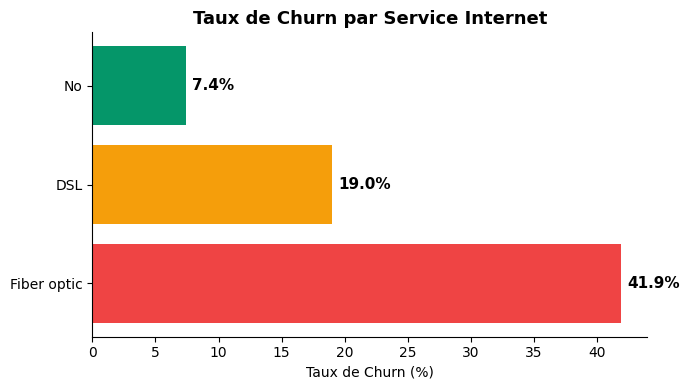

In [11]:
df_int_pd = churn_internet.toPandas()

fig, ax = plt.subplots(figsize=(7, 4))
colors_bar = ["#ef4444", "#f59e0b", "#059669"]
bars = ax.barh(df_int_pd["InternetService"], df_int_pd["Taux_Churn_%"],
               color=colors_bar[:len(df_int_pd)], edgecolor="none")
for bar, val in zip(bars, df_int_pd["Taux_Churn_%"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontsize=11, fontweight="bold")
ax.set_title("Taux de Churn par Service Internet", fontweight="bold", fontsize=13)
ax.set_xlabel("Taux de Churn (%)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout() ; plt.show()

## 💳 ÉTAPE 7 — Churn par Mode de Paiement

In [12]:
churn_paiement = df.groupBy("PaymentMethod").agg(
    count("*").alias("Total"),
    spark_sum(when(col("Churn") == "Yes", 1).otherwise(0)).alias("Churned"),
    spark_sum(when(col("Churn") == "No", 1).otherwise(0)).alias("Active")
).withColumn(
    "Taux_Churn_%", spark_round(col("Churned") / col("Total") * 100, 1)
).orderBy(desc("Taux_Churn_%"))

print("── Churn par Mode de Paiement ──")
churn_paiement.show(truncate=False)

churn_paiement.toPandas().to_csv(f"{OUTPUT_DIR}/analyse_churn_paiement.csv", index=False)
print("✅ Exporté : analyse_churn_paiement.csv")

── Churn par Mode de Paiement ──
+-------------------------+-----+-------+------+------------+
|PaymentMethod            |Total|Churned|Active|Taux_Churn_%|
+-------------------------+-----+-------+------+------------+
|Electronic check         |2365 |1071   |1294  |45.3        |
|Mailed check             |1604 |308    |1296  |19.2        |
|Bank transfer (automatic)|1542 |258    |1284  |16.7        |
|Credit card (automatic)  |1521 |232    |1289  |15.3        |
+-------------------------+-----+-------+------+------------+

✅ Exporté : analyse_churn_paiement.csv


## 💰 ÉTAPE 8 — Charges moyennes : Churned vs Actifs

In [13]:
charges_churn = df.groupBy("Churn").agg(
    spark_round(avg("MonthlyCharges"), 2).alias("Avg_MonthlyCharges"),
    spark_round(avg("TotalCharges"),   2).alias("Avg_TotalCharges"),
    spark_round(avg("tenure"),         1).alias("Avg_Tenure_Mois")
).orderBy("Churn")

print("── Charges et Ancienneté par Statut Churn ──")
charges_churn.show()

charges_churn.toPandas().to_csv(f"{OUTPUT_DIR}/analyse_charges_churn.csv", index=False)
print("✅ Exporté : analyse_charges_churn.csv")

── Charges et Ancienneté par Statut Churn ──
+-----+------------------+----------------+---------------+
|Churn|Avg_MonthlyCharges|Avg_TotalCharges|Avg_Tenure_Mois|
+-----+------------------+----------------+---------------+
|   No|             61.31|         2555.34|           37.7|
|  Yes|             74.44|          1531.8|           18.0|
+-----+------------------+----------------+---------------+

✅ Exporté : analyse_charges_churn.csv


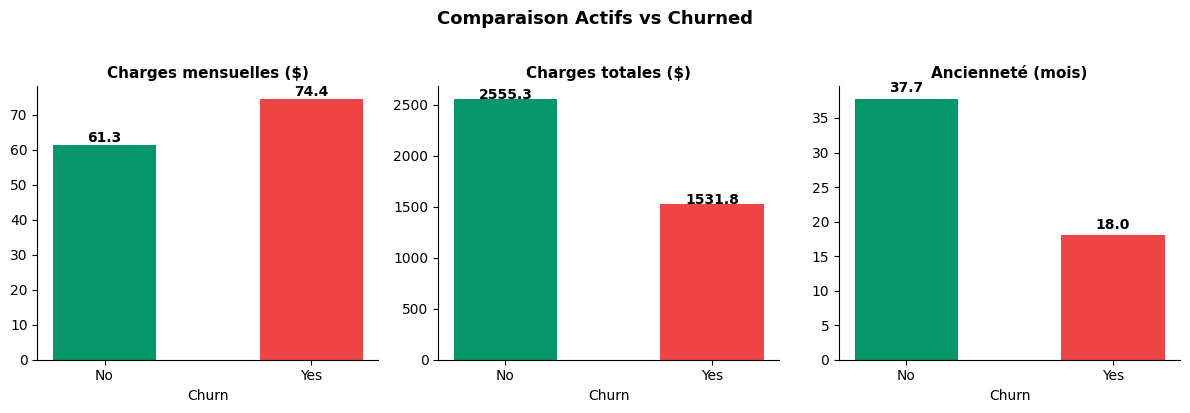

In [14]:
df_charges_pd = charges_churn.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = [("Avg_MonthlyCharges", "Charges mensuelles ($)"),
           ("Avg_TotalCharges",   "Charges totales ($)"),
           ("Avg_Tenure_Mois",    "Ancienneté (mois)")]
colors_group = ["#059669", "#ef4444"]

for ax, (metric, label) in zip(axes, metrics):
    bars = ax.bar(df_charges_pd["Churn"], df_charges_pd[metric],
                  color=colors_group, width=0.5, edgecolor="none")
    for bar, val in zip(bars, df_charges_pd[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val:.1f}", ha="center", fontsize=10, fontweight="bold")
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Churn") ; ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Comparaison Actifs vs Churned", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout() ; plt.show()

## 👥 ÉTAPE 9 — Churn par Profil Client (Senior, Partenaire, Dépendants)

In [15]:
profils = ["SeniorCitizen", "Partner", "Dependents"]
resultats = []

for profil in profils:
    res = df.groupBy(profil).agg(
        count("*").alias("Total"),
        spark_sum(when(col("Churn") == "Yes", 1).otherwise(0)).alias("Churned")
    ).withColumn(
        "Taux_Churn_%", spark_round(col("Churned") / col("Total") * 100, 1)
    ).withColumn("Profil", col(profil).cast("string")) \
     .withColumn("Categorie", 
         when(col(profil).cast("string") == "1", "Senior").otherwise(
         when(col(profil).cast("string") == "0", "Non-Senior").otherwise(
         col(profil).cast("string"))))
    res = res.select("Categorie", "Total", "Churned", "Taux_Churn_%") \
             .withColumn("Variable", col("Categorie").isNotNull().cast("string"))
    print(f"── {profil} ──")
    res.show()
    resultats.append(res.toPandas().assign(Variable=profil))

churn_profils = pd.concat(resultats, ignore_index=True)
churn_profils.to_csv(f"{OUTPUT_DIR}/analyse_churn_profils.csv", index=False)
print("✅ Exporté : analyse_churn_profils.csv")

── SeniorCitizen ──
+----------+-----+-------+------------+--------+
| Categorie|Total|Churned|Taux_Churn_%|Variable|
+----------+-----+-------+------------+--------+
|    Senior| 1142|    476|        41.7|    true|
|Non-Senior| 5890|   1393|        23.7|    true|
+----------+-----+-------+------------+--------+

── Partner ──
+---------+-----+-------+------------+--------+
|Categorie|Total|Churned|Taux_Churn_%|Variable|
+---------+-----+-------+------------+--------+
|       No| 3639|   1200|        33.0|    true|
|      Yes| 3393|    669|        19.7|    true|
+---------+-----+-------+------------+--------+

── Dependents ──
+---------+-----+-------+------------+--------+
|Categorie|Total|Churned|Taux_Churn_%|Variable|
+---------+-----+-------+------------+--------+
|       No| 4933|   1543|        31.3|    true|
|      Yes| 2099|    326|        15.5|    true|
+---------+-----+-------+------------+--------+

✅ Exporté : analyse_churn_profils.csv


## 📶 ÉTAPE 10 — Churn par Services Additionnels

In [16]:
services = ["OnlineSecurity", "TechSupport", "StreamingTV",
            "StreamingMovies", "OnlineBackup", "DeviceProtection"]
rows = []

for service in services:
    res = df.filter(col(service) != "No internet service") \
            .groupBy(service).agg(
                count("*").alias("Total"),
                spark_sum(when(col("Churn") == "Yes", 1).otherwise(0)).alias("Churned")
            ).withColumn("Taux_Churn_%",
                spark_round(col("Churned") / col("Total") * 100, 1)
            ).filter(col(service) == "No").collect()
    if res:
        rows.append({"Service": service, "Sans_service_Churn_%": res[0]["Taux_Churn_%"]})

df_services = pd.DataFrame(rows).sort_values("Sans_service_Churn_%", ascending=False)
print("── Taux de Churn chez les clients N'ayant PAS souscrit au service ──")
print(df_services.to_string(index=False))

df_services.to_csv(f"{OUTPUT_DIR}/analyse_churn_services.csv", index=False)
print("\n✅ Exporté : analyse_churn_services.csv")

── Taux de Churn chez les clients N'ayant PAS souscrit au service ──
         Service  Sans_service_Churn_%
  OnlineSecurity                  41.8
     TechSupport                  41.6
    OnlineBackup                  39.9
DeviceProtection                  39.1
 StreamingMovies                  33.7
     StreamingTV                  33.5

✅ Exporté : analyse_churn_services.csv


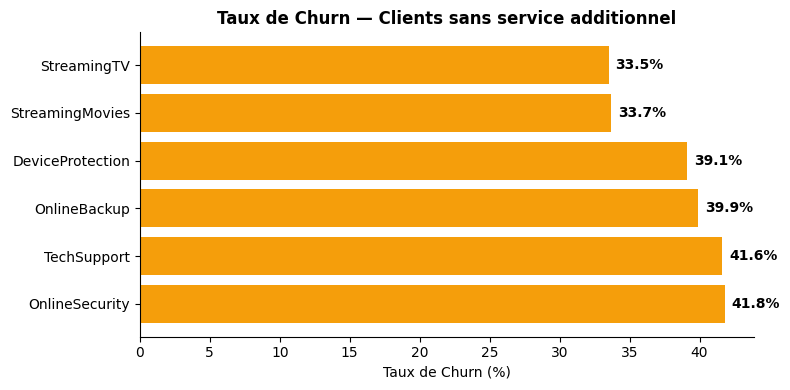

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
colors_s = ["#ef4444" if v > 50 else "#f59e0b" for v in df_services["Sans_service_Churn_%"]]
bars = ax.barh(df_services["Service"], df_services["Sans_service_Churn_%"],
               color=colors_s, edgecolor="none")
for bar, val in zip(bars, df_services["Sans_service_Churn_%"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontsize=10, fontweight="bold")
ax.set_title("Taux de Churn — Clients sans service additionnel", fontweight="bold", fontsize=12)
ax.set_xlabel("Taux de Churn (%)")
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout() ; plt.show()

## 📝 ÉTAPE 11 — Résumé des Insights clés

In [18]:
total = df.count()
churn_n = df.filter(col("Churn") == "Yes").count()
taux = round(churn_n / total * 100, 1)

insights = [
    f"📌 Taux de churn global : {taux}% ({churn_n}/{total} clients)",
    "📌 Les clients en contrat mensuel churent BEAUCOUP plus que 1 an / 2 ans",
    "📌 Fibre optique = taux de churn le plus élevé parmi les services internet",
    "📌 Les clients sans OnlineSecurity ni TechSupport churent plus",
    "📌 Les clients qui churent payent en moyenne plus par mois",
    "📌 Les clients qui churent ont une ancienneté moyenne plus courte",
]
print("\n=== INSIGHTS CLÉS ===")
for insight in insights:
    print(insight)

pd.DataFrame({"Insight": insights}).to_csv(f"{OUTPUT_DIR}/analyse_insights.csv", index=False)
print("\n✅ Exporté : analyse_insights.csv")


=== INSIGHTS CLÉS ===
📌 Taux de churn global : 26.6% (1869/7032 clients)
📌 Les clients en contrat mensuel churent BEAUCOUP plus que 1 an / 2 ans
📌 Fibre optique = taux de churn le plus élevé parmi les services internet
📌 Les clients sans OnlineSecurity ni TechSupport churent plus
📌 Les clients qui churent payent en moyenne plus par mois
📌 Les clients qui churent ont une ancienneté moyenne plus courte

✅ Exporté : analyse_insights.csv


## 🔚 ÉTAPE 12 — Fermer la session Spark

In [19]:
spark.stop()
print("✅ Session Spark fermée.")
print("📂 Fichiers exportés dans ../data/ :")
import os
for f in sorted(os.listdir("../data")):
    if f.startswith("analyse_"):
        print(f"   └─ {f}")

✅ Session Spark fermée.
📂 Fichiers exportés dans ../data/ :
   └─ analyse_charges_churn.csv
   └─ analyse_churn_contrat.csv
   └─ analyse_churn_global.csv
   └─ analyse_churn_internet.csv
   └─ analyse_churn_paiement.csv
   └─ analyse_churn_profils.csv
   └─ analyse_churn_services.csv
   └─ analyse_insights.csv
